# DIANYA Hackathon
## This notebook includes the executables blocks of code that we used to train our model. 

Clinical data was sourced in MIMIC III database.
Clinical factors were spoted by a team of physicians.



In [1]:
## This cell establishes our foundational libraries and loads the raw dataset into memory. 

import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb

print("--- Loading the Tidy Dataset ---")
df = pd.read_csv("main.csv")
print(f"Total Patients Loaded: {len(df)}")

--- Loading the Tidy Dataset ---
Total Patients Loaded: 2975


In [2]:
print("--- Matrix Separation & Scrubbing ---")
clinical_features = [
    'age', 'ast', 'alt', 'ast_alt_ratio', 'bilirubin', 
    'albumin', 'platelets', 'inr', 'creatinine', 'glucose'
]

# Upgraded Scrubbing Loop
for col in clinical_features:
    # Step 1: Force the column to be treated as strings temporarily
    df[col] = df[col].astype(str)
    
    # Step 2: Use Regex to delete '[' and ']' characters 
    # (The backslashes are escape characters because brackets usually mean something special in code)
    df[col] = df[col].str.replace(r'\[|\]', '', regex=True)
    
    # Step 3: Now that the brackets are gone, safely convert to numbers!
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types successfully scrubbed and brackets eliminated.")

--- Matrix Separation & Scrubbing ---
Data types successfully scrubbed and brackets eliminated.


now that we loaded, scrubed and  

In [3]:
##By isolating the filtering step, you can easily tweak the 0.25 threshold later to see how stricter or looser data quality requirements affect your model's final accuracy.

print("--- Patient Filtering ---")
# Calculate missingness percentage row-by-row
missing_ratio_per_row = df[clinical_features].isnull().mean(axis=1)

# Drop any patient missing more than 25% of their lab results
df_filtered = df[missing_ratio_per_row <= 0.25].copy()

rows_dropped = len(df) - len(df_filtered)
print(f"Patients dropped (>25% missing labs): {rows_dropped}")
print(f"Viable Patients Remaining: {len(df_filtered)}")

--- Patient Filtering ---
Patients dropped (>25% missing labs): 0
Viable Patients Remaining: 2975


### Now that we got what we wanted (except for the fib-4 score) we move to creating our model

In [4]:
print("--- MICE Imputation ---")
# Initialize the iterative imputer to predict missing lab values
mice_imputer = IterativeImputer(max_iter=10, random_state=42)

df_imputed = df_filtered.copy()
df_imputed[clinical_features] = mice_imputer.fit_transform(df_filtered[clinical_features])

print("Imputation complete. Zero missing values in clinical features.")

--- MICE Imputation ---
Imputation complete. Zero missing values in clinical features.


This is the most computationally expensive step of the data prep phase. Isolating this means once it finishes running, the imputed matrix is locked in memory, and you won't have to wait for it to recalculate if you are just experimenting with XGBoost parameters in a later cell.

In [5]:
print("--- Feature Engineering (Post-Imputation) ---")
# Calculate the FIB-4 index using the fully imputed age, AST, ALT, and platelets
denominator = df_imputed['platelets'] * np.sqrt(df_imputed['alt'])
df_imputed['FIB4_score_calculated'] = (df_imputed['age'] * df_imputed['ast']) / denominator

# Update our feature list to include the newly minted score
features_to_check = clinical_features + ['FIB4_score_calculated']
print("Derived features successfully calculated and appended.")

--- Feature Engineering (Post-Imputation) ---
Derived features successfully calculated and appended.


With a mathematically complete dataset, we can securely derive complex medical scores. Calculating FIB-4 is isolated here so you can easily add other derived features (like the AST/Platelet Ratio Index) in the future without disrupting the rest of the pipeline.

In [6]:
print("--- Feature Engineering (Post-Imputation) ---")
# Calculate the FIB-4 index using the fully imputed age, AST, ALT, and platelets
denominator = df_imputed['platelets'] * np.sqrt(df_imputed['alt'])
df_imputed['FIB4_score_calculated'] = (df_imputed['age'] * df_imputed['ast']) / denominator

# Update our feature list to include the newly minted score
features_to_check = clinical_features + ['FIB4_score_calculated']
print("Derived features successfully calculated and appended.")

--- Feature Engineering (Post-Imputation) ---
Derived features successfully calculated and appended.


In [7]:
from sklearn.model_selection import GroupShuffleSplit

print("--- Prepping Binary Target Variable & Splitting Data ---")
X = df_imputed[features_to_check].copy()

# THE FIX: Binary Target Engineering
# We mathematically flag MASH_NAFLD as 1, and every other disease as 0.
y_binary = (df_filtered['liver_group'] == 'MASH_NAFLD').astype(int)

# Isolate the subject_ids to prevent data leakage
groups = df_filtered['subject_id'].copy()

print(f"Total MASH patients (1): {y_binary.sum()}")
print(f"Total Other patients (0): {len(y_binary) - y_binary.sum()}")

# The Group-Aware Splitter
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y_binary, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_binary.iloc[train_idx], y_binary.iloc[test_idx]

print(f"\nTraining set: {len(X_train)} admissions.")
print(f"Testing set: {len(X_test)} admissions.")

--- Prepping Binary Target Variable & Splitting Data ---
Total MASH patients (1): 203
Total Other patients (0): 2772

Training set: 2381 admissions.
Testing set: 594 admissions.


This is your experimentation sandbox. Because everything above is already processed and sitting in memory, you can re-run this single cell in seconds to test different max_depth or learning_rate values to optimize your results

In [8]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import xgboost as xgb

print("--- Training the Binary XGBoost Model ---")

# Calculate the imbalance ratio to penalize the model for missing MASH
neg_cases = (y_train == 0).sum()
pos_cases = (y_train == 1).sum()
imbalance_weight = neg_cases / pos_cases

# Initialize the algorithm optimized for our specific binary problem
xgb_model = xgb.XGBClassifier(
    n_estimators=150,      
    learning_rate=0.05,    
    max_depth=4,           
    base_score=0.5,        # <-- THIS IS THE CRITICAL FIX!
    scale_pos_weight=imbalance_weight, 
    tree_method='hist',    
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)
print("Training Complete!\n")

print("--- The Final Exam (Evaluation) ---")
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1] 

roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC AUC Score: {roc_auc:.3f} (1.0 is perfect, 0.5 is random guessing)\n")

print("Detailed Diagnostic Report:")
print(classification_report(y_test, y_pred, target_names=['Other (0)', 'MASH-CKM (1)']))

--- Training the Binary XGBoost Model ---
Training Complete!

--- The Final Exam (Evaluation) ---
Overall Accuracy: 85.35%
ROC AUC Score: 0.743 (1.0 is perfect, 0.5 is random guessing)

Detailed Diagnostic Report:
              precision    recall  f1-score   support

   Other (0)       0.95      0.89      0.92       554
MASH-CKM (1)       0.19      0.38      0.26        40

    accuracy                           0.85       594
   macro avg       0.57      0.63      0.59       594
weighted avg       0.90      0.85      0.87       594



--- Generating Clinical Feature Importance (Native) ---


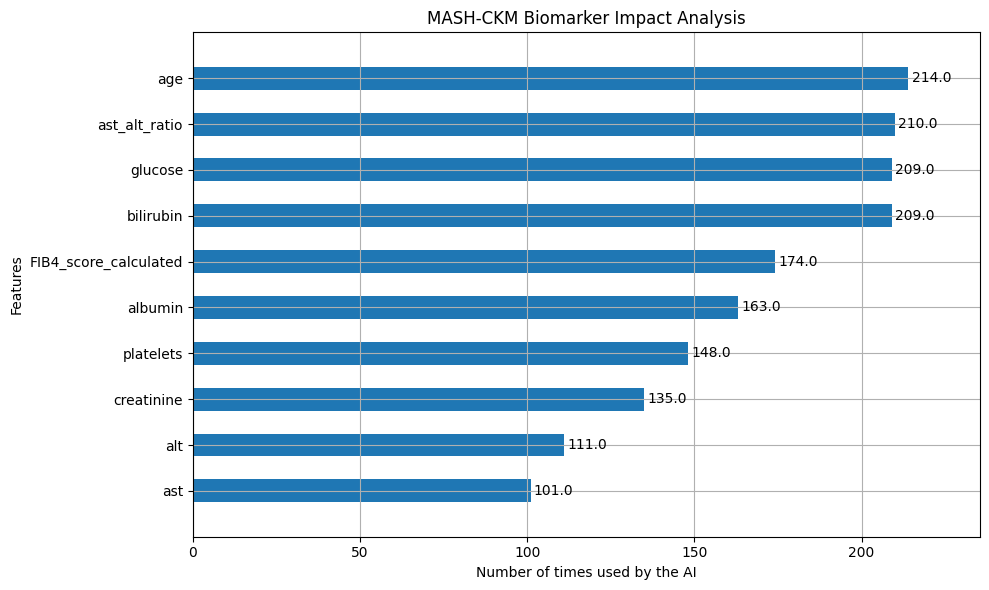

In [9]:
import matplotlib.pyplot as plt
import xgboost as xgb

print("--- Generating Clinical Feature Importance (Native) ---")
# XGBoost's built-in explainer
# importance_type='weight' counts how many times a feature was used to make a clinical decision
ax = xgb.plot_importance(
    xgb_model, 
    importance_type='weight',
    title='MASH-CKM Biomarker Impact Analysis',
    xlabel='Number of times used by the AI',
    max_num_features=10, # Show the top 10
    height=0.5
)

# Make the graph larger and easier to read
fig = ax.figure
fig.set_size_inches(10, 6)
plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np
import json
import ollama

print("--- 1. Loading Comprehensive Seed Data ---")
df_real = pd.read_csv("main.csv")

# We include all the raw biological and demographic markers from your screenshot
# (We exclude IDs because they are meaningless to an LLM, and we exclude the math ratios)
features_to_mimic = [
    'gender', 'age', 'icd9_code', 'liver_group', 
    'ast', 'alt', 'bilirubin', 'albumin', 'platelets', 
    'inr', 'creatinine', 'glucose'
]

# Grab our teacher examples
mash_examples = df_real[df_real['liver_group'] == 'MASH_NAFLD'].head(3)[features_to_mimic]
other_examples = df_real[df_real['liver_group'] != 'MASH_NAFLD'].head(3)[features_to_mimic]

seed_data = pd.concat([mash_examples, other_examples]).to_dict(orient='records')
seed_json = json.dumps(seed_data, indent=2)
print("Expanded seed data successfully extracted.")

print("\n--- 2. Engineering the Advanced Prompt ---")
num_patients = 50 

system_prompt = (
    "You are an expert clinical data generator. Your ONLY job is to output raw JSON. "
    "You must output a single JSON object containing a 'patients' key. "
    "The 'patients' key must contain a list of the records."
)

user_prompt = f"""
Generate EXACTLY {num_patients} NEW synthetic patient records. 
Half should be "MASH_NAFLD" and half should be "Other".

Here is the real seed data for reference:
{seed_json}

You MUST return the data in this exact JSON structure, ensuring all clinical markers are medically realistic for the given liver_group:
{{
  "patients": [
    {{ 
      "gender": "M", 
      "age": 45, 
      "icd9_code": "571.8", 
      "liver_group": "MASH_NAFLD",
      "ast": 55.0, 
      "alt": 48.0, 
      "bilirubin": 1.2, 
      "albumin": 3.8, 
      "platelets": 150.0, 
      "inr": 1.1, 
      "creatinine": 0.9, 
      "glucose": 120.0
    }},
    ... ({num_patients - 1} more objects) ...
  ]
}}
"""

print(f"--- 3. Requesting {num_patients} Comprehensive Patients from Qwen2.5 ---")
try:
    response = ollama.chat(
        model='qwen2.5:7b',
        messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user', 'content': user_prompt}
        ],
        format='json', 
        options={'temperature': 0.7} 
    )

    raw_json_string = response['message']['content'].strip()
    
    print("--- 4. Tabulating and Engineering Final Scores ---")
    synthetic_data = json.loads(raw_json_string)
    
    if "patients" in synthetic_data:
        patient_list = synthetic_data["patients"]
    else:
        patient_list = synthetic_data if isinstance(synthetic_data, list) else [synthetic_data]
        
    df_synthetic = pd.DataFrame(patient_list)
    
    # THE MATH OVERRIDE: We calculate the ratios perfectly in Pandas
    df_synthetic['ast_alt_ratio'] = df_synthetic['ast'] / df_synthetic['alt']
    
    denominator = df_synthetic['platelets'] * np.sqrt(df_synthetic['alt'])
    df_synthetic['fib4_score'] = (df_synthetic['age'] * df_synthetic['ast']) / denominator
    
    print(f"Success! Generated full clinical profiles with a loscal LLM.")
    display(df_synthetic)

except Exception as e:
    print(f"Error during generation or parsing: {e}")
    print(f"\nRaw LLM Output for debugging:\n{raw_json_string}")

--- 1. Loading Comprehensive Seed Data ---
Expanded seed data successfully extracted.

--- 2. Engineering the Advanced Prompt ---
--- 3. Requesting 50 Comprehensive Patients from Qwen2.5 ---
--- 4. Tabulating and Engineering Final Scores ---
Success! Generated full clinical profiles with a loscal LLM.


,gender,age,icd9_code,liver_group,ast,alt,bilirubin,albumin,platelets,inr,creatinine,glucose,ast_alt_ratio,fib4_score
0,M,58,571.8,MASH_NAFLD,46.0,32.0,0.9,4.0,185.0,1.0,0.7,130.0,1.437500,2.549407
1,F,42,571.8,MASH_NAFLD,60.0,38.0,0.8,4.2,175.0,1.1,0.9,135.0,1.578947,2.335988
2,M,60,571.8,MASH_NAFLD,42.0,36.0,0.7,4.1,195.0,1.2,0.8,130.0,1.166667,2.153846
3,F,47,571.8,MASH_NAFLD,52.0,30.0,0.6,4.3,180.0,1.0,0.9,125.0,1.733333,2.478952
4,M,46,571.8,MASH_NAFLD,53.0,28.0,0.8,4.0,170.0,1.1,0.9,130.0,1.892857,2.710228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,F,49,571.8,MASH_NAFLD,63.0,32.0,0.7,4.0,185.0,1.1,0.9,125.0,1.968750,2.949782
58,M,43,571.8,MASH_NAFLD,46.0,29.0,0.8,4.1,175.0,1.1,0.9,130.0,1.586207,2.098888
59,F,46,571.8,MASH_NAFLD,62.0,32.0,0.7,4.0,185.0,1.0,0.9,130.0,1.937500,2.725228
60,M,47,571.8,MASH_NAFLD,46.0,30.0,0.6,4.2,175.0,1.0,0.8,130.0,1.533333,2.255574


### We locally run this LLM in order to produce tabulated data much like the real data from mimic III we got. This sidesteps the mimic III privacy agreement as well as highlighting the fact that this is real private clinical data.

In [18]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

print("--- 1. The Safe Merge (Augmenting Training Data ONLY) ---")
# Vertically stack the synthetic patients strictly underneath the real training patients
X_train_augmented = pd.concat([X_train, X_synthetic], ignore_index=True)
y_train_augmented = pd.concat([y_train, y_synthetic], ignore_index=True)

print(f"Original Training Size: {len(X_train)} admissions")
print(f"Augmented Training Size: {len(X_train_augmented)} admissions")

print("\n--- 2. Retraining the XGBoost Model on Augmented Data ---")
# Recalculate our class imbalance weight since we just injected more patients
neg_cases = (y_train_augmented == 0).sum()
pos_cases = (y_train_augmented == 1).sum()
imbalance_weight = neg_cases / pos_cases

# Initialize the model with the same optimized Apple Silicon parameters
xgb_augmented = xgb.XGBClassifier(
    n_estimators=150,      
    learning_rate=0.05,    
    max_depth=4,           
    base_score=0.5,        
    scale_pos_weight=imbalance_weight, 
    tree_method='hist',    
    random_state=42
)

# Train the model on the massive new dataset
xgb_augmented.fit(X_train_augmented, y_train_augmented)
print("Augmented Training Complete!\n")

print("--- 3. The Final Exam (Pure Human Testing Vault) ---")
# Test the model ONLY on the pure, 20% real human data we locked away earlier
y_pred = xgb_augmented.predict(X_test)
y_pred_proba = xgb_augmented.predict_proba(X_test)[:, 1] 

roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC AUC Score: {roc_auc:.3f}\n")

print("Detailed Diagnostic Report:")
print(classification_report(y_test, y_pred, target_names=['Other (0)', 'MASH-CKM (1)']))

--- 1. The Safe Merge (Augmenting Training Data ONLY) ---
Original Training Size: 2381 admissions
Augmented Training Size: 2443 admissions

--- 2. Retraining the XGBoost Model on Augmented Data ---
Augmented Training Complete!

--- 3. The Final Exam (Pure Human Testing Vault) ---
Overall Accuracy: 87.04%
ROC AUC Score: 0.746

Detailed Diagnostic Report:
              precision    recall  f1-score   support

   Other (0)       0.95      0.90      0.93       554
MASH-CKM (1)       0.23      0.40      0.29        40

    accuracy                           0.87       594
   macro avg       0.59      0.65      0.61       594
weighted avg       0.91      0.87      0.89       594



In [19]:
print("--- Prepping the Synthetic Data ---")

# THE FIX: Standardize the column name to perfectly match your real dataset
if 'fib4_score' in df_synthetic.columns:
    df_synthetic = df_synthetic.rename(columns={'fib4_score': 'FIB4_score_calculated'})

# Now we safely extract the exact columns our model expects
features_needed = X_train.columns.tolist()

# Convert Qwen's text labels into the 0 and 1 binary math
y_synthetic = (df_synthetic['liver_group'] == 'MASH_NAFLD').astype(int)

# Isolate just the mathematical features 
X_synthetic = df_synthetic[features_needed].copy()

print(f"Successfully prepped {len(X_synthetic)} synthetic patients for merging.")

--- Prepping the Synthetic Data ---
Successfully prepped 62 synthetic patients for merging.


In [20]:
print("--- Saving Data to Hard Drive ---")

# 1. Save the raw synthetic patients Qwen just generated
df_synthetic.to_csv("synthetic_patients_qwen.csv", index=False)
print("✅ Saved: synthetic_patients_qwen.csv")

# 2. Save your fully merged, augmented training sets 
X_train_augmented.to_csv("X_train_augmented.csv", index=False)
y_train_augmented.to_csv("y_train_augmented.csv", index=False)
print("✅ Saved: Augmented training matrices.")

--- Saving Data to Hard Drive ---
✅ Saved: synthetic_patients_qwen.csv
✅ Saved: Augmented training matrices.


### We succesfully created an augmented dataset to train our model on. 